d:\ScienceAPPs\Anaconda\envs\Quantum_tools_in_python\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


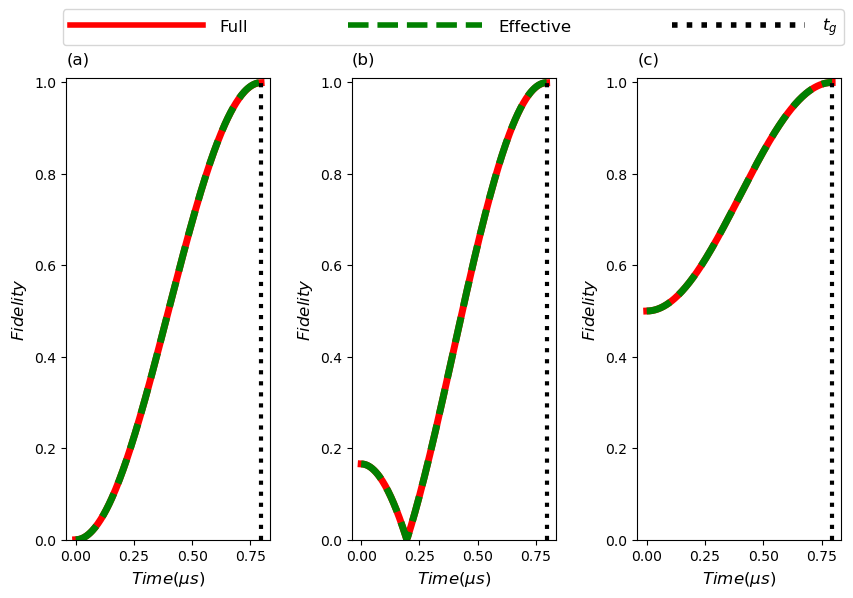

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# ========================================================================================================================================================================================
# 1. 保真度计算
# ========================================================================================================================================================================================
import re
from matplotlib import style
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from qutip import * # type: ignore #quantum tools in python
from IPython import *
from IPython.display import display, Math
# ============================================================
# 1.1参数设置
# ============================================================

Omega_a = 2 * np.pi * (20 / 3) # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Omega_b = 1.2 * Omega_a # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Delta_a = (15 / 2) * Omega_a #大失谐条件
Delta_b = Delta_a * (Omega_b**2) / (Omega_a**2) #比例关系

V = 2 * Delta_a - (3*Omega_a**2) / (4 * Delta_a) #RII V应满足的关系(求解出来的)

gamma =1.5e-3 #1.5e-3 MHz(参考2016 S.L Su)
gamma_A = 2 * np.pi #2pi MHz(参考2016 S.L Su)

g = Omega_a**2 / (2 * Delta_a) #Heff中耦合强度g
t_g = np.sqrt(2) * np.pi * Delta_a / (Omega_a**2) #计算得到的CNOT门实现时间

# ============================================================
# 1.2 基矢|ij>...|kl>定义，外积|ij><kl|定义
# ============================================================

N = 4
i0, i1, iA, ir = 0, 1, 2, 3

def ket(i, j):
    return tensor(basis(N, i), basis(N, j))

def P(i, j, k, l):
    return ket(i, j) * ket(k, l).dag()

# ============================================================
# 1.3 有效哈密顿量(论文中计算得到)
# ============================================================


def H_eff(g):
    H_eff = g * (
    ket(1,0) * ket(3,3).dag() +
    ket(1,1) * ket(3,3).dag() +
    ket(3,3) * ket(1,0).dag() +
    ket(3,3) * ket(1,1).dag()
    )
    return H_eff

def H_full(Omega_a, Omega_b, Delta_a):

    Delta_b = Delta_a * (Omega_b**2 / Omega_a**2)
    Delta_diff = Delta_a - Delta_b
    Delta_tilde = 2 * Delta_a * Delta_b / (Delta_a + Delta_b)

    H = 0

    # ===== 第一大行 =====
    c1 = Omega_a**2/(4*Delta_a) - Omega_b**2/(4*Delta_b)
    H += c1 * (
        P(i0,i0,i0,i0) + P(i0,i1,i0,i1)
      + P(i0,i0,i0,i1) + P(i0,i1,i0,i0)
      + P(i1,i0,i1,i1) + P(i1,i1,i1,i0)
      + P(iA,i0,iA,i1) + P(iA,i1,iA,i0)
    ) #*

    # ===== Stark shifts =====
    H +=  ((Omega_b**2)/(2*Delta_b)) * P(i0,iA,i0,iA)  #*

    H += -((Omega_a**2)/(2*Delta_a)) * P(i0,ir,i0,ir)  #*

    H += ((Omega_a**2)/(2*Delta_a) - (Omega_b**2)/(2*Delta_b))* (P(i1,i0,i1,i0) + P(i1,i1,i1,i1)) #*

    H += ((Omega_a**2)/(4*Delta_a)+(Omega_b**2)/(4*Delta_b)) * P(i1,iA,i1,iA) #*

    H += -((3*Omega_a**2)/(4*Delta_a)+(Omega_b**2)/(4*Delta_b)) * P(i1,ir,i1,ir) #*

    H += -((Omega_a**2)/(2*Delta_a))*(P(i1,ir,ir,i0)+P(ir,i0,i1,ir)+P(i1,ir,ir,i1)+P(ir,i1,i1,ir))#*

    H += (Omega_a**2)/(4*Delta_a) * (P(iA,i0,iA,i0) + P(iA,i1,iA,i1)) #*

    H += ((3*Omega_a**2)/(4*Delta_a)) * P(iA,iA,iA,iA) #*

    H += ((Omega_b**2)/(4*Delta_b) - (Omega_a**2)/(2*Delta_a)) * P(iA,ir,iA,ir) #*

    H += -((Omega_a**2)/(2*Delta_a) + (Omega_b**2)/(4*Delta_b)) * (P(ir,i0,ir,i0) + P(ir,i1,ir,i1)) #*

    H += -((Omega_a**2)/(4*Delta_a)+(Omega_b**2)/(4*Delta_b)) * (P(ir,i0,ir,i1) + P(ir,i1,ir,i0)) #*

    H += ((Omega_b**2)/(2*Delta_b) - (Omega_a**2)/(4*Delta_a)) * P(ir,iA,ir,iA) #*

    # H += ((3*Omega_a**2)/(4*Delta_a)) * P(ir,ir,ir,ir) #使V满足V=2Δ_a - (3Ω_a^2)/(4Δ_a)时,这一项可省略

    # ===== (|10>+|11>) ↔ |rr| + h.c. =====
    H_rr = ((Omega_a**2)/(2*Delta_a)) * ( P(i1,i0,ir,ir) + P(i1,i1,ir,ir)) #*

    H += H_rr + H_rr.dag() #*

    # ===== Time-dependent coupling =====
    H_plus = ((Omega_a*Omega_b)/(4*Delta_tilde)) * (P(ir,ir,iA,ir) + P(ir,ir,ir,iA))

    H_minus = H_plus.dag()

    H_td = [
        [H_plus,  lambda t, args: np.exp(1j * Delta_diff * t)],
        [H_minus, lambda t, args: np.exp(-1j * Delta_diff * t)]
    ]

    return [H] + H_td
# ============================================================
# 1.4 Lindblad 算符(查阅了Qutip文档后，按照其标准形式定义)
# ============================================================

c_ops = []

#原子1的Lindblad算符
c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N)),
]

#原子2的Lindblad算符
c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
]

# ============================================================
# 1.5 理想相位修正CNOT门(返回的是理想相位修正CNOT门作用后的态即U_cnot_correct|state>)，
# ============================================================
# 因为本方案实现的矩阵是
# [0,1,0,0//
# 0,0,1,0//
# 0,0,0,-1;
# 0,0,-1,0]
#所以需要相位修正

def ideal_cnot(state):
    psi_cnot = (
        (ket(0,0).dag() * state) * ket(0,0) +
        (ket(0,1).dag() * state) * ket(0,1) +
        (ket(1,0).dag() * state) * ket(1,1) +
        (ket(1,1).dag() * state) * ket(1,0)
    )

    psi_corrected = (
        ket(0,0)*ket(0,0).dag()*psi_cnot +
        ket(0,1)*ket(0,1).dag()*psi_cnot -
        ket(1,0)*ket(1,0).dag()*psi_cnot -
        ket(1,1)*ket(1,1).dag()*psi_cnot
    )#修正后的CNOT门

    return psi_corrected #返回的是理想相位修正CNOT门作用后的态即U_cnot_correct|state>

# ============================================================
# 1.6  保真度随时间变化的函数定义
# ============================================================
# 主要计算由qutip库内置函数fidelity完成
def state_fidelity_vs_time(H, psi0, psi_ideal, t_list, c_ops):
    result = mesolve(H, psi0, t_list, c_ops, [])
    return [fidelity(psi_ideal, rho) for rho in result.states]


# ============================================================
# 1.7 初始态分量系数对应a,b,c三图
# ============================================================

initial_states = [
    (0.5, 0.5, 0.5, 0.5),
    (np.sqrt(0.1), np.sqrt(0.3), np.sqrt(0.4), np.sqrt(0.2)),
    (np.sqrt(0.4),np.sqrt(0.1), 0, np.sqrt(0.5)),
    
]

# ============================================================
# 1.8 演化时间轴
# ============================================================

t_list = np.linspace(0, t_g, 201)

# ============================================================
# 1.9 作图
# ============================================================

# 创建一个1行3列的子图，用于分别绘制三种初始态下的保真度演化
fig, axes = plt.subplots(1, 3, figsize=(10,6))

# -------- 参数说明--------
# 在图的左上角添加参数说明文本框，包含主要物理参数
# fig.text(
#     0.01, 0.98,
#     r"Parameters: "
#     r"$\Omega_a/2\pi = %.2f\,\mathrm{MHz},\ "
#     r"\Delta_a/\Omega_a = %.1f,\ "
#     r"g/2\pi = %.3f\,\mathrm{MHz},\ "
#     r"t_g = %.2f\,\mathrm{\mu s},\ "
#     r"\gamma/2\pi = %.3f\,\mathrm{kHz},"
#     r"\gamma_A/2\pi = %.3f\,\mathrm{MHz}$"
#     % (
#         Omega_a/(2*np.pi),
#         Delta_a/Omega_a,
#         g/(2*np.pi),
#         t_g,
#         gamma/(2*np.pi)*1e3,
#         gamma_A/(2*np.pi)
#     ),
#     ha="left", va="top", fontsize=11,
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
# )


# 遍历三组初始态参数，分别计算并绘制每种初始态下的保真度演化
for idx, (a, b, c, d) in enumerate(initial_states): # a,b,c,d为初始态分量系数

    # 构造初始态并归一化
    psi0 = (a*ket(0,0) + b*ket(0,1) + c*ket(1,0) + d*ket(1,1)).unit()
    # 计算理想相位修正CNOT门作用下的目标态，即调用ideal_cnot函数
    psi_ideal = ideal_cnot(psi0)
 
    # 1).有效H_eff下计算每个时刻的保真度，即F(t)=<psi_ideal|rho|psi_ideal>
    fidelity_diss = state_fidelity_vs_time(H_eff(g), psi0, psi_ideal, t_list, c_ops)

    # 2).总哈密顿量H_full情况下的计算每个时刻的保真度
    fidelity_coh = state_fidelity_vs_time(H_full(Omega_a,Omega_b,Delta_a), psi0, psi_ideal, t_list, c_ops)

    # 绘制当前初始态下的保真度曲线
    ax = axes[idx]
    ax.plot(t_list, fidelity_coh, 'r-', lw=5)  # H_full
    ax.plot(t_list, fidelity_diss, 'g--', lw=5)  # H_eff
    ax.axvline(t_g, color='k', ls=':', lw=3)  # 门操作时间的竖线

    # 设置子图标题，显示初始态信息
    ax.set_title(
        "(%s)"%(chr(97+idx)),
        loc='left',
        pad=10,
        fontsize=12,
    )
    
    ax.set_xlabel(r"$Time (\mu s)$",fontsize=12)  # 横坐标标签
    ax.set_ylabel(r"$Fidelity$",fontsize=12)   # 纵坐标标签
    ax.set_ylim(0, 1.01)        # 保真度范围
    

proxy_artists = [
    Line2D([0], [0], color='red', linestyle='-', linewidth=4, label='Full'),
    Line2D([0], [0], color='green', linestyle='--', linewidth=4, label='Effective'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=4, label=r'$t_g$')
]


fig.legend(
    handles=proxy_artists, 
    bbox_to_anchor=(0.012, -0.02, 1,1),  # 与图形等宽
    loc='upper center',          # 锚点位置
    mode='none',                   # 默认模式
    ncol=3,                      # 3列
    borderaxespad=-0.5,           # 边框内边距
    columnspacing=6,           # 列间距
    handlelength=8.0,            # 图例句柄长度
    handletextpad=1,           # 句柄与文本间距
    fontsize=12,
    fancybox=True
)

# 调整子图布局，避免重叠
# plt.tight_layout(rect=[0, 0, 1.2 , 0.9])
plt.subplots_adjust(wspace=0.4)
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\1.eps')
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\1.pdf')
plt.show()

# 输出每种初始态在门操作时间 t_g 时的保真度（有耗散）
display(Math(r"\text{Fidelity at gate time } t_g \text{ (Effective):}"))
for idx, (a, b, c, d) in enumerate(initial_states):
    psi0 = (a*ket(0,0) + b*ket(0,1) + c*ket(1,0) + d*ket(1,1)).unit()
    psi_ideal = ideal_cnot(psi0)
    result = mesolve(H_eff(g), psi0, t_list, c_ops)
    F = fidelity(psi_ideal, result.states[-1])
    display(Math(fr"({chr(97+idx)})\quad F(t_g) = {F:.6f}"))


display(Math(r"\text{Fidelity at gate time } t_g \text{ (Full):}"))
for idx, (a, b, c, d) in enumerate(initial_states):
    psi0 = (a*ket(0,0) + b*ket(0,1) + c*ket(1,0) + d*ket(1,1)).unit()
    psi_ideal = ideal_cnot(psi0)
    result = mesolve(H_full(Omega_a, Omega_b, Delta_a), psi0, t_list, c_ops)
    F = fidelity(psi_ideal, result.states[-1])
    display(Math(fr"({chr(97+idx)})\quad F(t_g) = {F:.6f}"))


d:\ScienceAPPs\Anaconda\envs\Quantum_tools_in_python\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=0.0 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=1.6 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=3.2 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=4.8 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=6.4 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=8.1 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=9.7 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=11.3 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=12.9 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=14.5 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=16.1 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=17.7 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=19.3 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=20.9 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=22.6 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=24.2 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=25.8 MHz, F=1.0000
$gamma/2\pi$=0.0 kHz, $gamma_A/2\pi$=27.4 MHz, F=1.0000

<IPython.core.display.Math object>

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


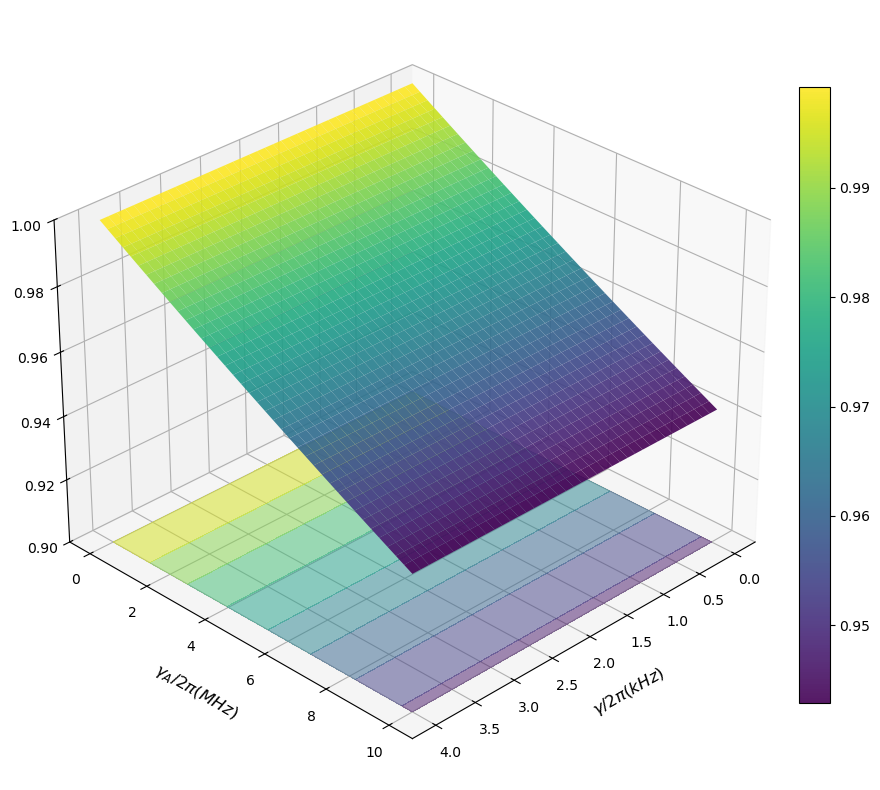

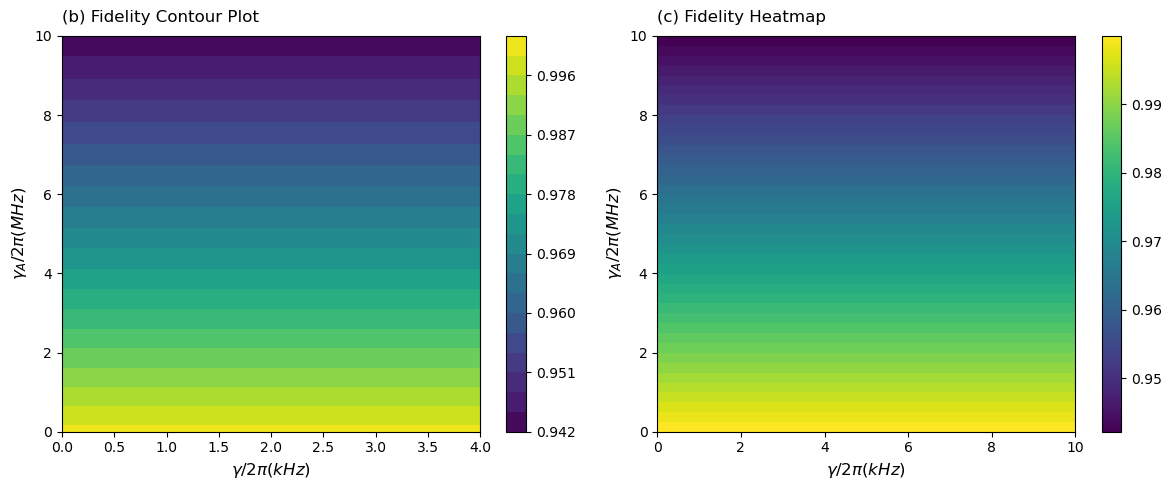

In [2]:
# ========================================================================================================================================================================================
# 2. 三维保真度图gamma和gamma_A变化对Fidelity的影响曲面图
# ========================================================================================================================================================================================
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Math
# ============================================================
# 2.1 定义参数扫描范围
# ============================================================
# 注意：MHz和kHz，需要转换
Omega_a = 20/3 # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Omega_b = 1.2 * Omega_a # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Delta_a = (15 / 2) * Omega_a #大失谐条件(50MHz)(参考2016 S.L Su)
Delta_b = Delta_a * (Omega_b**2) / (Omega_a**2) #比例关系

gamma_A_over2pi = np.linspace(0, 10, 40)  # γ_A/2π，单位：MHz (0-10 MHz)
gamma_over2pi = np.linspace(0, 4, 40)    # γ/2π，单位：kHz (0-10 kHz)

# 转换为角频率
gamma_A_vals = gamma_A_over2pi * 2 * np.pi  # γ_A单位(MHz)
gamma_vals = gamma_over2pi * 1e-3 * 2 * np.pi  # γ从kHz转换为MHz(1kHz=1e-3 MHz)

g = Omega_a**2 / (2 * Delta_a) #Heff中耦合强度g


def ideal_cnot(state):
    psi_cnot = (
        (ket(0,0).dag() * state) * ket(0,0) +
        (ket(0,1).dag() * state) * ket(0,1) +
        (ket(1,0).dag() * state) * ket(1,1) +
        (ket(1,1).dag() * state) * ket(1,0)
    )

    psi_corrected = (
        ket(0,0)*ket(0,0).dag()*psi_cnot +
        ket(0,1)*ket(0,1).dag()*psi_cnot -
        ket(1,0)*ket(1,0).dag()*psi_cnot -
        ket(1,1)*ket(1,1).dag()*psi_cnot
    )#修正后的CNOT门

    return psi_corrected #返回的是理想相位修正CNOT门作用后的态即U_cnot_correct|state>

def H_eff(g):
    H_eff = g * (
    ket(1,0) * ket(3,3).dag() +
    ket(1,1) * ket(3,3).dag() +
    ket(3,3) * ket(1,0).dag() +
    ket(3,3) * ket(1,1).dag()
    )
    return H_eff



t_g = np.sqrt(2) * np.pi * Delta_a / (Omega_a**2) #计算得到的CNOT门实现时间

t_list = np.linspace(0, t_g, 201)
# ============================================================
# 
# ============================================================

psi0 = (0.5*ket(0,0) + 0.5*ket(0,1) + 0.5*ket(1,0) + 0.5*ket(1,1)).unit()
psi_ideal = ideal_cnot(psi0)

F_3d = np.zeros((len(gamma_vals), len(gamma_A_vals)))

def state_fidelity_vs_time(H, psi0, psi_ideal, t_list, c_ops):
    result = mesolve(H, psi0, t_list, c_ops, [])
    return [fidelity(psi_ideal, rho) for rho in result.states]

for i, gamma_val in enumerate(gamma_vals):
    for j, gamma_A_val in enumerate(gamma_A_vals):
        c_ops_local = []
    
    # 原子1的L算符
        c_ops_local += [
            np.sqrt(gamma_val)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
            np.sqrt(gamma_val)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),
            np.sqrt(gamma_A_val) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N)),
            np.sqrt(gamma_A_val) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N)),
            ]
    
    # 原子2的L算符
        c_ops_local += [
            np.sqrt(gamma_val)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
            np.sqrt(gamma_val)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
            np.sqrt(gamma_A_val) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
            np.sqrt(gamma_A_val) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
            ]

        F_3d[i, j] = state_fidelity_vs_time(H_eff(g), psi0, psi_ideal, t_list, c_ops_local)[-1]
        print(f"$gamma/2\pi$={gamma_vals[i]:.1f} kHz, $gamma_A/2\pi$={gamma_A_vals[j]:.1f} MHz, F={F_3d[i,j]:.4f}")

# ============================================================
# 2.3 创建三维数据网格
# ============================================================
display(Math(r"\text{绘制} \gamma-\gamma_A-\text{Fidelity曲面}"))


# ============================================================
# 2.4 创建三维曲面图
# ============================================================

fig_3d = plt.figure(figsize=(12, 8))

# #在图的左上角添加参数说明文本框，包含主要物理参数
# fig_3d.text(
#     0.01, 0.98,
#     r"Parameters: "
#     r"$\Omega_a/2\pi = %.2f\,\mathrm{MHz},\ "
#     r"\Delta_a/\Omega_a = %.1f,\ "
#     r"g/2\pi = %.3f\,\mathrm{MHz}\ $ "

#     % (
#         Omega_a/(2*np.pi),
#         Delta_a/Omega_a,
#         g/(2*np.pi),

#     ),
#     ha="left", va="top", fontsize=11,
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
# )

ax_3d = fig_3d.add_subplot(111, projection='3d')

# 创建网格
GAMMA, GAMMA_A = np.meshgrid(gamma_over2pi, gamma_A_over2pi)

# 绘制曲面
surf = ax_3d.plot_surface(GAMMA, GAMMA_A, F_3d, 
                         cmap='viridis',  # 使用viridis色彩映射
                         linewidth=0, 
                         alpha=0.9)

# 设置视角
ax_3d.view_init(elev=30, azim=45)  # 调整视角，elev=仰角，azim=方位角

# 设置标签
ax_3d.set_xlabel('$\gamma/2\pi (kHz)$', fontsize=12, labelpad=10)
ax_3d.set_ylabel('$\gamma_A/2\pi (MHz)$', fontsize=12, labelpad=10)
ax_3d.set_zlabel('$Fidelity$', fontsize=12, labelpad=10)
# ax_3d.set_title('\n\n (a) Fidelity with respect to $\gamma_A/2\pi$ and $\gamma/2\pi$ at the $t_g$', fontsize=12, loc='left',pad=10)

# 添加颜色条
cbar = fig_3d.colorbar(surf, ax=ax_3d, shrink=0.8, aspect=20,pad=0.01)

# 设置Z轴Fidelity范围
ax_3d.set_zlim(0.9, 1)

# 显示网格
ax_3d.grid(True, alpha=0.5)

# ============================================================
# 2.5 绘制其等高线投影
# ============================================================
# 在底部投影等高线
ax_3d.contourf(GAMMA, GAMMA_A, F_3d, zdir='z', offset=0.90, cmap='viridis', alpha=0.5)


plt.tight_layout()
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\2.eps')
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\2.pdf')
plt.show()

# ============================================================
# 2.6 保存数据
# ============================================================
#np.savez('fidelity_3d_data.npz', 
#         gamma_values=gamma_values, 
#         gamma_A_values=gamma_A_values, 
#         fidelity=F_3d)
#print("三维保真度数据已保存到 fidelity_3d_data.npz")

# ============================================================
# 2.7 绘制其二维等高线图与热图
# ============================================================
fig_2d, ax_2d = plt.subplots(1, 2, figsize=(12, 5))

# 左图：等高线
contour = ax_2d[0].contourf(GAMMA, GAMMA_A, F_3d, levels=20, cmap='viridis')
ax_2d[0].set_xlabel('$\gamma/2\pi (kHz)$',fontsize=12)
ax_2d[0].set_ylabel('$\gamma_A/2\pi (MHz)$',fontsize=12)

ax_2d[0].set_title('(b) Fidelity Contour Plot',fontsize=12,loc='left',pad=10)
fig_2d.colorbar(contour, ax=ax_2d[0])

# 右图：热图
im = ax_2d[1].imshow(F_3d, extent=[0, 10, 0, 10], origin='lower', aspect='auto', cmap='viridis')
ax_2d[1].set_xlabel('$\gamma/2\pi (kHz)$',fontsize=12)
ax_2d[1].set_ylabel('$\gamma_A/2\pi (MHz)$',fontsize=12)

ax_2d[1].set_title('(c) Fidelity Heatmap',fontsize=12,loc='left',pad=10)
fig_2d.colorbar(im, ax=ax_2d[1])

plt.tight_layout()
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\3.eps')
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\3.pdf')
plt.show()


d:\ScienceAPPs\Anaconda\envs\Quantum_tools_in_python\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


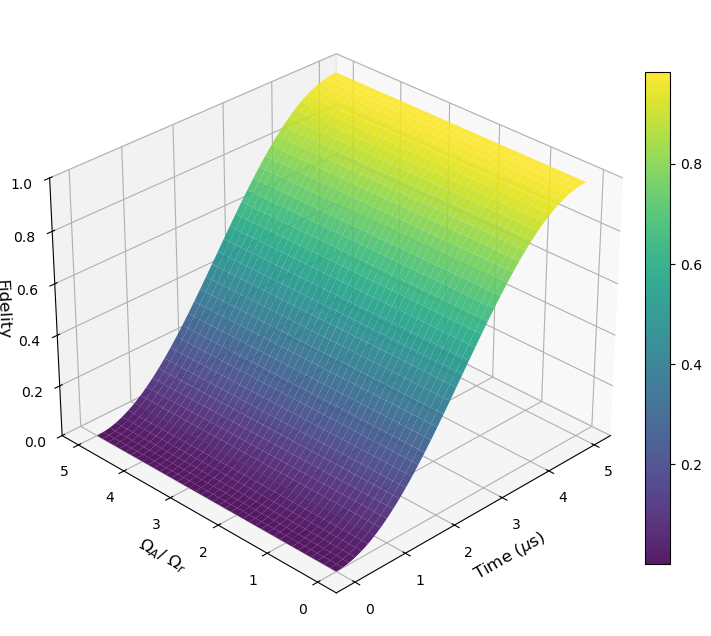

In [3]:
# ========================================================================================================================================================================================
from numpy import meshgrid
import numpy as np
import matplotlib.pyplot as plt
from qutip import * #quantum tools in python
from IPython import *
from IPython.display import display, Math

Omega_a = 20/3 # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Delta_a = (15 / 2) * Omega_a #大失谐条件(50MHz)(参考2016 S.L Su)
t_g = np.sqrt(2) * np.pi * Delta_a / (Omega_a**2) #计算得到的CNOT门实现时间
t_list = np.linspace(0, t_g, 201)
Omega_b =np.linspace(1.1*Omega_a,5*Omega_a, 201) # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Δ_tilde_inv = (1/Delta_a + 1/Delta_b) / 2
Δ_tilde = 1/Δ_tilde_inv  # 等效失谐

gamma =2 * np.pi*1e-3      #2pi kHz(参考2016 S.L Su)
gamma_A = 2 * np.pi*2     #4pi MHz(参考2016 S.L Su)
# ============================================================
V = 2 * Delta_a - (3*Omega_a**2) / (4 * Delta_a) #RII V应满足的关系(求解出来的)
g = Omega_a**2 / (2 * Delta_a) #Heff中耦合强度g


# ============================================================
# 函数定义
# ============================================================
N = 4
i0, i1, iA, ir = 0, 1, 2, 3

def ket(i, j):
    return tensor(basis(N, i), basis(N, j))

def P(i, j, k, l):
    return ket(i, j) * ket(k, l).dag()

def H_eff(g):
    H_eff = g * (
    ket(1,0) * ket(3,3).dag() +
    ket(1,1) * ket(3,3).dag() +
    ket(3,3) * ket(1,0).dag() +
    ket(3,3) * ket(1,1).dag()
    )
    return H_eff

def ideal_cnot(state):
    psi_cnot = (
        (ket(0,0).dag() * state) * ket(0,0) +
        (ket(0,1).dag() * state) * ket(0,1) +
        (ket(1,0).dag() * state) * ket(1,1) +
        (ket(1,1).dag() * state) * ket(1,0)
    )

    psi_corrected = (
        ket(0,0)*ket(0,0).dag()*psi_cnot +
        ket(0,1)*ket(0,1).dag()*psi_cnot -
        ket(1,0)*ket(1,0).dag()*psi_cnot -
        ket(1,1)*ket(1,1).dag()*psi_cnot
    )#修正后的CNOT门

    return psi_corrected #返回的是理想相位修正CNOT门作用后的态即U_cnot_correct|state>

# ============================================================
# Lindblad 算符(查阅了Qutip文档后，按照其标准形式定义，耗散系数定义方式与原文gamma/2,gamma_A/2等价)
# ============================================================

c_ops = []

#原子1的L算符
c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N)),
]

#原子2的L算符
c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
]

# ========================================================================================================================================================================================
# 2. 保真度 vs 时间 vs \Omega_b / \Omega_a 的三维图像（在第一段代码基础上添加，假设第一段代码已完整运行，所有变量如 H_eff、c_ops、t_list、ideal_cnot、initial_states 等已定义）
# ========================================================================================================================================================================================

# 使用第一种初始态（与原图 (a) 对应，即均匀叠加态）
initial_states = [
    (0.5, 0.5, 0.5, 0.5),
    (np.sqrt(0.1), np.sqrt(0.2), np.sqrt(0.3), np.sqrt(0.4)),
    (np.sqrt(0.4),np.sqrt(0.1), 0, np.sqrt(0.5)),
    
]

(a, b, c, d) = initial_states[0]
psi0 = (0.5*ket(0,0) + 0.5*ket(0,1) + 0.5*ket(1,0) + 0.5*ket(1,1)).unit()
psi_ideal = ideal_cnot(psi0)


# 有耗散情况下的演化（一次性计算所有时间点的保真度）
result_diss = mesolve(H_eff(g), psi0, t_list, c_ops, [])
fidelity_diss = np.array([
    fidelity(psi_ideal, rho)
    for rho in result_diss.states
])

# \Omega_b / \Omega_a 的扫描范围（0 ~ 5，与原第二段代码意图一致）
num_points = 201
omega_ratio = np.linspace(0, 5, num_points)

# 由于有效哈密顿量 H_eff 和耗散算符 c_ops 不依赖于 \Omega_b（通过比例调整 \Delta_b 保持 g 不变），
# 保真度曲线在 \Omega_b 方向上完全相同，体现对 \Omega_b 波动的高鲁棒性
F_3d0 = np.tile(fidelity_diss, (num_points, 1))  # 形状：(num_points, len(t_list))

# 网格化用于三维绘图
T, OMEGA_RATIO = np.meshgrid(t_list, omega_ratio)

# 创建三维曲面图
fig_3d = plt.figure(figsize=(12, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# 绘制曲面
surf = ax_3d.plot_surface(
    T, OMEGA_RATIO, F_3d0,
    cmap='viridis', alpha=0.9, linewidth=0, antialiased=True
)

# 坐标轴标签
ax_3d.view_init(elev=30, azim=45+180)  # 调整视角，elev=仰角，azim=方位角
ax_3d.set_xlabel(r'Time ($\mu$s)',fontsize=12)
ax_3d.set_ylabel(r'$\Omega_A $/ $\Omega_r$',fontsize=12)
ax_3d.set_zlabel(r'Fidelity',rotation=180,fontsize=12,labelpad=1)
ax_3d.set_zlim(0, 1.00)

# 颜色条
fig_3d.colorbar(surf, shrink=0.8, aspect=20, pad=0.01)

# # 可选：在名义值 \Omega_b / \Omega_a = 1.2 处标一条黑线（突出原参数点）
# nominal_ratio = 1.2
# ax_3d.plot(
#     t_list, 
#     np.full_like(t_list, nominal_ratio), 
#     fidelity_diss, 
#     color='black', linewidth=3, linestyle='-', 
#     label=r'nominal \( \Omega_b / \Omega_a = 1.2 \)'
# )
# ax_3d.legend(loc='upper left')
# ax_3d.zaxis.labelpad=0

plt.show()

d:\ScienceAPPs\Anaconda\envs\Quantum_tools_in_python\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


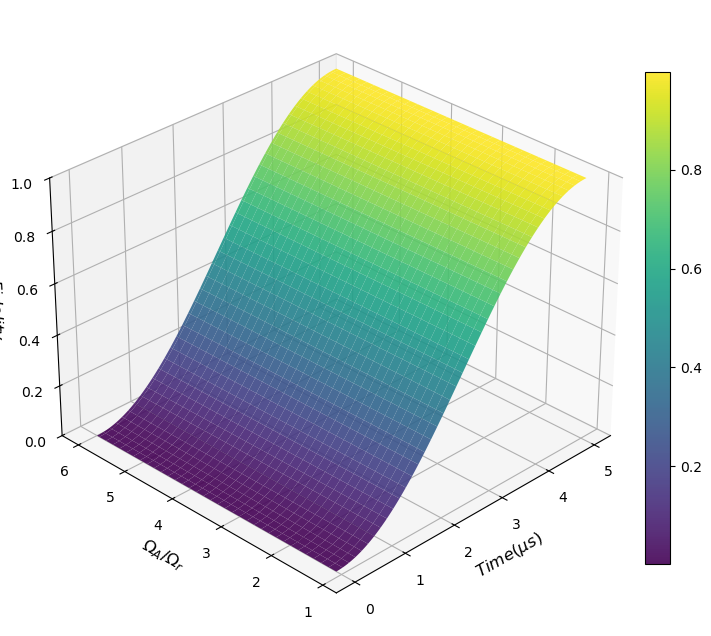

In [4]:
# ======================================================================
# Full Hamiltonian simulation                           要的图
# Fidelity vs time vs Omega_b / Omega_a
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ============================================================
# 1. Parameters
# ============================================================
Omega_a = 20/3          # MHz
Delta_a = 50            # MHz

t_g = np.sqrt(2) * np.pi * Delta_a / (Omega_a**2)
t_list = np.linspace(0, t_g, 201)

Omega_b_list = np.linspace(1.1*Omega_a, 6*Omega_a,101)
Omega_b_list = Omega_b_list[Omega_b_list != Omega_a]
    # H += ((3*Omega_a**2)/(4*Delta_a)) * P(ir,ir,ir,ir) #使V满足V=2Δ_a - (3Ω_a^2)/(4Δ_a),


# ============================================================
# 2. Basis
# ============================================================
N = 4
i0, i1, iA, ir = 0, 1, 2, 3

def ket(i, j):
    return tensor(basis(N, i), basis(N, j))

def P(i, j, k, l):
    return ket(i, j) * ket(k, l).dag()

# ============================================================
# 3. Ideal CNOT
# ============================================================

def ideal_cnot(state):
    psi_cnot = (
        (ket(0,0).dag() * state) * ket(0,0) +
        (ket(0,1).dag() * state) * ket(0,1) +
        (ket(1,0).dag() * state) * ket(1,1) +
        (ket(1,1).dag() * state) * ket(1,0)
    )

    psi_corrected = (
        ket(0,0)*ket(0,0).dag()*psi_cnot +
        ket(0,1)*ket(0,1).dag()*psi_cnot -
        ket(1,0)*ket(1,0).dag()*psi_cnot -
        ket(1,1)*ket(1,1).dag()*psi_cnot
    )#修正后的CNOT门

    return psi_corrected #返回的是理想相位修正CNOT门作用后的态即U_cnot_correct|state>

# ============================================================
# 4. Initial state
# ============================================================
psi0 = (0.5*ket(0,0) + 0.5*ket(0,1) + 0.5*ket(1,0) + 0.5*ket(1,1)).unit()
psi_ideal = ideal_cnot(psi0)

# ============================================================
# 5. Hamiltonian builder (Original Hamiltonian)
# ============================================================
def build_hamiltonian(Omega_a, Omega_b, Delta_a):

    Delta_b = Delta_a * (Omega_b**2 / Omega_a**2)
    Delta_diff = Delta_a - Delta_b
    Delta_tilde = 2 * Delta_a * Delta_b / (Delta_a + Delta_b)

    H = 0

    # ===== 第一大行 =====
    c1 = Omega_a**2/(4*Delta_a) - Omega_b**2/(4*Delta_b)
    H += c1 * (
        P(i0,i0,i0,i0) + P(i0,i1,i0,i1)
      + P(i0,i0,i0,i1) + P(i0,i1,i0,i0)
      + P(i1,i0,i1,i1) + P(i1,i1,i1,i0)
      + P(iA,i0,iA,i1) + P(iA,i1,iA,i0)
    ) #*

    # ===== Stark shifts =====
    H +=  ((Omega_b**2)/(2*Delta_b)) * P(i0,iA,i0,iA)  #*

    H += -((Omega_a**2)/(2*Delta_a)) * P(i0,ir,i0,ir)  #*

    H += ((Omega_a**2)/(2*Delta_a) - (Omega_b**2)/(2*Delta_b))* (P(i1,i0,i1,i0) + P(i1,i1,i1,i1)) #*

    H += ((Omega_a**2)/(4*Delta_a)+(Omega_b**2)/(4*Delta_b)) * P(i1,iA,i1,iA) #*

    H += -((3*Omega_a**2)/(4*Delta_a)+(Omega_b**2)/(4*Delta_b)) * P(i1,ir,i1,ir) #*

    H += -((Omega_a**2)/(2*Delta_a))*(P(i1,ir,ir,i0)+P(ir,i0,i1,ir)+P(i1,ir,ir,i1)+P(ir,i1,i1,ir))#*

    H += (Omega_a**2)/(4*Delta_a) * (P(iA,i0,iA,i0) + P(iA,i1,iA,i1)) #*

    H += ((3*Omega_a**2)/(4*Delta_a)) * P(iA,iA,iA,iA) #*

    H += ((Omega_b**2)/(4*Delta_b) - (Omega_a**2)/(2*Delta_a)) * P(iA,ir,iA,ir) #*

    H += -((Omega_a**2)/(2*Delta_a) + (Omega_b**2)/(4*Delta_b)) * (P(ir,i0,ir,i0) + P(ir,i1,ir,i1)) #*

    H += -((Omega_a**2)/(4*Delta_a)+(Omega_b**2)/(4*Delta_b)) * (P(ir,i0,ir,i1) + P(ir,i1,ir,i0)) #*

    H += ((Omega_b**2)/(2*Delta_b) - (Omega_a**2)/(4*Delta_a)) * P(ir,iA,ir,iA) #*

    # H += ((3*Omega_a**2)/(4*Delta_a)) * P(ir,ir,ir,ir) #使V满足V=2Δ_a - (3Ω_a^2)/(4Δ_a)时,这一项可省略

    # ===== (|10>+|11>) ↔ |rr| + h.c. =====
    H_rr = ((Omega_a**2)/(2*Delta_a)) * ( P(i1,i0,ir,ir) + P(i1,i1,ir,ir)) #*

    H += H_rr + H_rr.dag() #*

    # ===== Time-dependent coupling =====
    H_plus = ((Omega_a*Omega_b)/(4*Delta_tilde)) * (P(ir,ir,iA,ir) + P(ir,ir,ir,iA))

    H_minus = H_plus.dag()

    H_td = [
        [H_plus,  lambda t, args: np.exp(1j * Delta_diff * t)],
        [H_minus, lambda t, args: np.exp(-1j * Delta_diff * t)]
    ]

    return [H] + H_td


# ============================================================
# 6. Scan Omega_b
# ============================================================
F_3d = np.zeros((len(Omega_b_list), len(t_list)))

options = Options(nsteps=10000000)
for i, Omega_b in enumerate(Omega_b_list):

    H = build_hamiltonian(Omega_a, Omega_b, Delta_a)

    result = mesolve(
        H,
        psi0,
        t_list,
        c_ops=[],
        e_ops=[]
    )

    F_3d[i, :] = [
        fidelity(psi_ideal, state)
        for state in result.states
    ]

# ============================================================
# 7. 3D Plot
# ============================================================

T, OMEGA_RATIO = np.meshgrid(t_list, Omega_b_list / Omega_a)

fig = plt.figure(figsize=(12, 8))

#参数说明
# fig.text(
#     0.01, 0.98,
#     r"Parameters: "
#     r"$\Omega_a/2\pi = %.2f\,\mathrm{MHz},\ "
#     r"\Delta_a/\Omega_a = %.1f$,\ "
   

#     % (
#         Omega_a/(2*np.pi),
#         Delta_a/Omega_a,


#     ),
#     ha="left", va="top", fontsize=11,
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
# )
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    T, OMEGA_RATIO, F_3d,
    cmap="viridis",
    linewidth=0,alpha=0.9
)

ax.set_xlabel(r"$Time(\mu s)$",fontsize=12)
ax.set_ylabel(r"$\Omega_A / \Omega_r$",fontsize=12)
ax.set_zlabel(r"$Fidelity$",rotation=180,fontsize=12)
ax.set_zlim(0, 1.0)
ax.view_init(30, 45+180)

fig.colorbar(surf, shrink=0.8, aspect=20, pad=0.01)
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\4.eps')
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\4.pdf')
plt.show()

d:\ScienceAPPs\Anaconda\envs\Quantum_tools_in_python\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


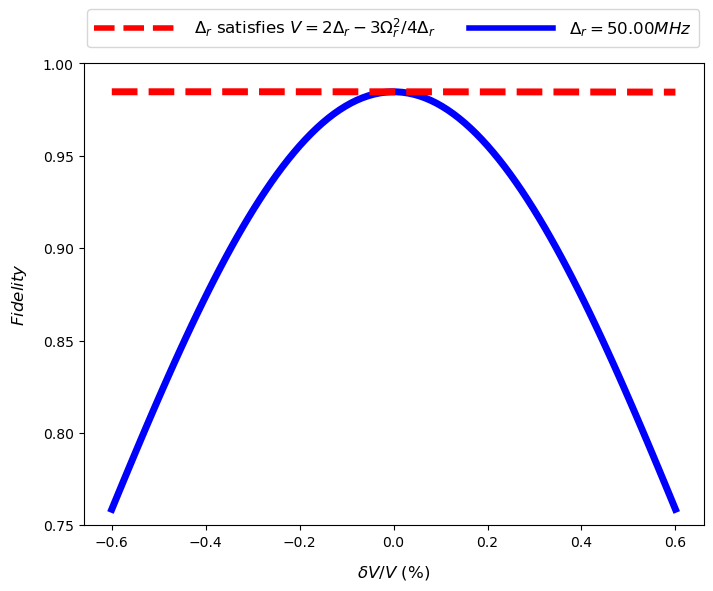

In [5]:
# ========================================================================================================================================================================================
# 3. 保真度图随δV/V变化                                 要的图
# ========================================================================================================================================================================================
# ============================================================
# 3.1 参数设置
# ============================================================
from math import sqrt
from tkinter import font
import numpy as np
import matplotlib.pyplot as plt
from pyparsing import line
from qutip import * #quantum tools in python
from IPython import *

Omega_a = 20/3 # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Omega_b = 1.2 * Omega_a # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)

Delta_a_0 = (15 / 2) * Omega_a #大失谐条件(50MHz)(参考2016 S.L Su)
Delta_b = Delta_a_0 * (Omega_b**2) / (Omega_a**2) #比例关系

gamma =2 * np.pi*1e-3      #2pi kHz(参考2016 S.L Su)
gamma_A = 2 * np.pi*2     #4pi MHz(参考2016 S.L Su)

t_g0 = sqrt(2) * np.pi * Delta_a_0 / Omega_a**2 #计算得到
t_list0 = np.linspace(0, t_g0, 201) 

g1 = Omega_a**2 / (2 * Delta_a_0) #Heff中耦合强度g

# 相对误差 ε = δV / V0
Eps_list = np.linspace(-0.006, 0.006, 100)

# 未经δV扰动时的RRI强度
V0 = 2 * Delta_a_0 - (3 * Omega_a**2) / (4 * Delta_a_0) #由论文中RRI关系求得

# ============================================================
# 耗散算符（i0, i1, ir, iA 之前已定义）
# ============================================================

c_ops = []

c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N)),
]

c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
]

# ============================================================
# 初态与理想目标态
# ============================================================
def ket(i, j):
    return tensor(basis(N, i), basis(N, j))

def P(i, j, k, l):
    return ket(i, j) * ket(k, l).dag()

def ideal_cnot(state):
    psi_cnot = (
        (ket(0,0).dag() * state) * ket(0,0) +
        (ket(0,1).dag() * state) * ket(0,1) +
        (ket(1,0).dag() * state) * ket(1,1) +
        (ket(1,1).dag() * state) * ket(1,0)
    )

    psi_corrected = (
        ket(0,0)*ket(0,0).dag()*psi_cnot +
        ket(0,1)*ket(0,1).dag()*psi_cnot -
        ket(1,0)*ket(1,0).dag()*psi_cnot -
        ket(1,1)*ket(1,1).dag()*psi_cnot
    )#修正后的CNOT门

    return psi_corrected #返回的是理想相位修正CNOT门作用后的态即U_cnot_correct|state>

(a, b, c, d) = initial_states[0]          #选择第一种初始态，均匀population
psi0 = (0.5*ket(0,0) + 0.5*ket(0,1) + 0.5*ket(1,0) + 0.5*ket(1,1)).unit()

psi_ideal = ideal_cnot(psi0)              #理想CNOT门作用后的目标态

# ============================================================
# Fidelity 计算
# ============================================================

fidelity_without_adjusted_tg  = []   #未调整 Δa 满足条件V后,tg时刻的保真度列表
fidelity_with_adjusted_tg = []       #调整失谐 Δa 满足 V=2Δa-(3Ωa^2)/(4Δa) 后,tg时刻的保真度列表

# ============================================================
# 未调整 Δa 满足条件V后,tg时刻的保真度计算
# ============================================================
for eps in Eps_list:

    delta_V = eps * V0

    result_without_adjusted = mesolve(H_eff(g1) + delta_V * ket(3,3) * ket(3,3).dag(), psi0, t_list0, c_ops, [])    #加入扰动后的RRI项
    F_without_adjusted = fidelity(psi_ideal,result_without_adjusted.states[-1])
    fidelity_without_adjusted_tg.append(F_without_adjusted)

# ============================================================
# 调整失谐 Δa 满足 V 后,tg时刻的保真度计算
# ============================================================
for eps in Eps_list:
    
    V= V0 * (1 + eps) #实际RRI
    Delta_a_adjusted = (4*V+sqrt(16*(V**2)+96*Omega_a**2))/16 #调整后的失谐
    Delta_b_adjusted = Delta_a_adjusted * (Omega_b**2) / (Omega_a**2) #调整后的失谐比例关系
    g2 = Omega_a**2 / (2 * Delta_a_adjusted) #Heff中耦合强度g

    result_with_adjusted = mesolve(H_eff(g2), psi0, t_list0, c_ops, [])
    F_with_adjusted = fidelity(psi_ideal,result_with_adjusted.states[-1])
    fidelity_with_adjusted_tg.append(F_with_adjusted)
# ============================================================
# 绘制
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# -------- 参数说明--------
# 在图的左上角添加参数说明文本框，包含主要物理参数
# fig.text(
#     0.01, 0.98,
#     r"Parameters: "
#     r"$\Omega_a = %.2f\,\mathrm{MHz},\ "
#     r"t_g = %.2f\,\mathrm{\mu s},\ "
#     r"\gamma/2\pi = %.3f\,\mathrm{kHz},"
#     r"\gamma_A/2\pi = %.3f\,\mathrm{MHz}$"
#     % (
#         Omega_a,
#         t_g0,
#         gamma*1e3/(2*np.pi),
#         gamma_A/(2*np.pi)
#     ),

#     ha="left", va="top", fontsize=11,
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
# )


# 绘制曲线

line1, = ax.plot(Eps_list*100, fidelity_without_adjusted_tg, color='blue',lw=5, label=r'$\Delta_a= %.2f MHz$' % Delta_a_0,alpha=1)
line2, = ax.plot(Eps_list*100, fidelity_with_adjusted_tg, color='red',lw=5, ls='--', label=r'$\Delta_a$ satisfies $V=2\Delta_a-3\Omega_a^2/4\Delta_a$',alpha=1)



# 标记最高点
# ax.scatter(Eps_list[np.argmax(fidelity_without_adjusted_tg)] * 100, fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)], color='green', s=150, zorder=5, marker='*')
# ax.annotate(f'Max: {fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]:.4f}', 
#             xy=(Eps_list[np.argmax(fidelity_without_adjusted_tg)] * 100, fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]), 
#             xytext=(Eps_list[np.argmax(fidelity_without_adjusted_tg)] * 100+0.04, fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]-0.07),
#             arrowprops=dict(facecolor='red', shrink=0.05, width=3),
#             fontsize=12,
#             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))

# 只在图例中显示最高点信息
# 绘制曲线（注意：line1, 和 line2, 开头有逗号）

# 设置图例
proxy_artists = [
    Line2D([0], [0], color='red', linestyle='--', linewidth=4, label=r'$\Delta_r$ satisfies $V=2\Delta_r-3\Omega_r^2/4\Delta_r$'),
    Line2D([0], [0], color='blue', linestyle='-', linewidth=4, label=r'$\Delta_r= %.2f MHz$' % Delta_a_0),

]


fig.legend(
    handles=proxy_artists, 
    bbox_to_anchor=(0.012, -0.03, 1,1),  # 与图形等宽
    loc='upper center',          # 锚点位置
    mode='none',                   # 默认模式
    ncol=3,                      # 3列
    borderaxespad=0,           # 边框内边距
    columnspacing=2,           # 列间距
    handlelength=5.0,            # 图例句柄长度
    handletextpad=1,           # 句柄与文本间距
    fontsize=12,

)


ax.set_xlabel(r'$\delta V / V$ (%)',fontsize=12,labelpad=10)
ax.set_ylabel('$Fidelity$',fontsize=12,labelpad=10)

# ax.set_title('\n\n Fidelity with respect of $\delta V / V$ at $t_g$')  ##################
ax.set_ylim(0.75, 1.0)
# plt.tight_layout()
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\5.eps')
plt.savefig('D:\\虚拟c盘\\Papers\\毕业\\5.pdf')
plt.show()



